# Verification of Bounded Variance of Stochastic Gradients

### Objective

The objective of this experiment is to verify whether the variance of stochastic gradients remains
bounded.

A bounded gradient variance ensures that the stochastic updates produced by SGD do not fluctuate
excessively, contributing to stable optimization and convergence.

The experiment is run at the **trained model weights** loaded from a checkpoint. Section 3
optionally repeats the measurement across several checkpoints, which tests whether the variance
stays bounded along the training trajectory rather than at a single point.

### Methodology

1. Load the trained model from a checkpoint.
2. Sample multiple random mini-batches for different batch sizes.
3. Compute the gradient for each mini-batch.
4. Estimate the variance of the stochastic gradients.
5. Analyze how the gradient variance changes with batch size.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.nn import CrossEntropyLoss

from src.utils import load_config, set_seed
from src.data import get_dataloaders
from manual_nn.models import SimpleCNN

os.environ["CUDA_VISIBLE_DEVICES"] = "7"

In [4]:
# ---- fill this in -------------------------------------------------------
CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "checkpoints/best_model.pth")
# -------------------------------------------------------------------------

config = load_config(os.path.join(PROJECT_ROOT, "configs/data.yaml"))
model_cfg = load_config(os.path.join(PROJECT_ROOT, "configs/model.yaml"))

set_seed(config.get("seed", 42))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


### Step 1: Load the Trained Model

In [5]:
def load_checkpoint(model, checkpoint_path, device):
    """Load manually-stored weights, same convention as src/tester.py."""
    checkpoint = torch.load(checkpoint_path, map_location=device)

    layer_id = 0
    for layer in model.layers:
        if hasattr(layer, "weights"):
            layer.weights = checkpoint[f"layer_{layer_id}.weights"].to(device)
            layer.bias = checkpoint[f"layer_{layer_id}.bias"].to(device)
            layer_id += 1

    print(f"Loaded {layer_id} parameter layers from {checkpoint_path}")
    return model


model = SimpleCNN(model_cfg).to(device)
model = load_checkpoint(model, CHECKPOINT_PATH, device)
loss_fn = CrossEntropyLoss()


Loaded 4 parameter layers from /vision01_scratch/rajat/et-robo/problem1_mnist/checkpoints/best_model.pth


### Step 2: Estimate Gradient Variance at Each Batch Size

In [6]:
def gradient_variance(model, batch_sizes, num_trials=200):
    """Mean squared deviation of mini-batch gradients from their own mean."""
    results = {}

    for batch_size in batch_sizes:
        loader, _, _ = get_dataloaders(
            data_dir=config["root"], batch_size=batch_size, shuffle=True
        )

        gradients = []
        count = 0

        for x, y in tqdm(loader, leave=False, desc=f"batch {batch_size}"):
            x, y = x.to(device), y.to(device)

            model.zero_grad()

            logits = model.forward(x)
            probs = F.softmax(logits, dim=1)
            targets = F.one_hot(y, num_classes=model_cfg["num_classes"]).float()
            grad_logits = (probs - targets) / y.size(0)

            model.backward(grad_logits)

            grad = torch.cat([g.flatten() for g in model.gradients()])
            gradients.append(grad)

            count += 1
            if count == num_trials:
                break

        gradients = torch.stack(gradients)
        mean_grad = gradients.mean(dim=0)
        results[batch_size] = ((gradients - mean_grad) ** 2).sum(dim=1).mean().item()

    return results


batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
variance_results = gradient_variance(model, batch_sizes, num_trials=200)

for bs, v in variance_results.items():
    print(f"  batch {bs:>4}: variance {v:.4f}")


  batch    1: variance 515.7101
  batch    2: variance 129.1196
  batch    4: variance 108.9220
  batch    8: variance 52.5158
  batch   16: variance 22.1831
  batch   32: variance 13.5492
  batch   64: variance 6.0070
  batch  128: variance 3.2483
  batch  256: variance 1.6333
  batch  512: variance 0.8369


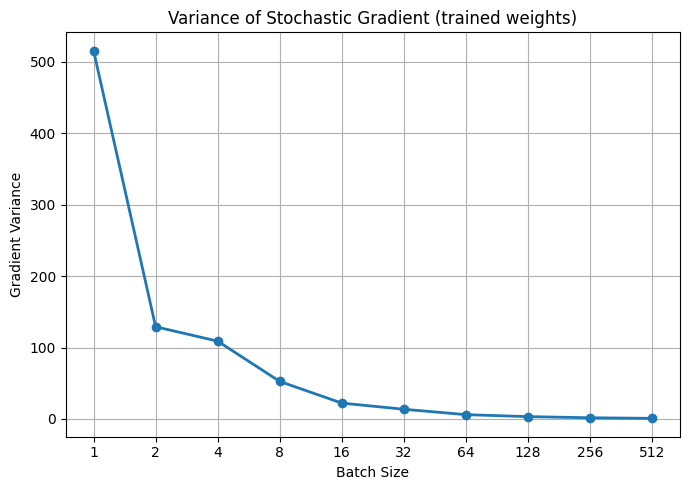

In [7]:
plt.figure(figsize=(7, 5))

plt.plot(variance_results.keys(), variance_results.values(), marker="o", linewidth=2)

plt.xscale("log", base=2)
plt.xticks(batch_sizes, batch_sizes)
plt.xlabel("Batch Size")
plt.ylabel("Gradient Variance")
plt.title("Variance of Stochastic Gradient (trained weights)")
plt.grid(True)

plt.tight_layout()
plt.savefig("fig_variance.png", dpi=200)
plt.show()


### What does this figure tell?

- Small mini-batches exhibit higher gradient variance because fewer samples contribute to each
  gradient estimate.
- As the batch size increases, the variance decreases since gradients are averaged over more
  samples.
- The variance remains finite for all evaluated batch sizes.
- These observations support the bounded variance assumption commonly used in SGD convergence
  analysis.


### Step 3 (optional): Variance Along the Training Trajectory

Measuring at one set of weights shows the variance is bounded *there*. The assumption used in SGD
convergence analysis asks for a bound that holds throughout training. Repeating the measurement at
several checkpoints tests that directly.

Fill in the checkpoint paths below and run; skip this section if only one checkpoint was saved.


In [ ]:
# ---- fill these in (epoch label -> checkpoint path) ---------------------
CHECKPOINTS = {
    # "epoch 0":  os.path.join(PROJECT_ROOT, "checkpoints/epoch_0.pt"),
    # "epoch 10": os.path.join(PROJECT_ROOT, "checkpoints/epoch_10.pt"),
    # "epoch 19": os.path.join(PROJECT_ROOT, "checkpoints/epoch_19.pt"),
}
# -------------------------------------------------------------------------

trajectory_results = {}

for label, path in CHECKPOINTS.items():
    print(f"\n=== {label}")
    ckpt_model = SimpleCNN(model_cfg).to(device)
    ckpt_model = load_checkpoint(ckpt_model, path, device)
    trajectory_results[label] = gradient_variance(ckpt_model, batch_sizes, num_trials=200)

if trajectory_results:
    plt.figure(figsize=(7, 5))
    for label, res in trajectory_results.items():
        plt.plot(res.keys(), res.values(), marker="o", linewidth=2, label=label)

    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xticks(batch_sizes, batch_sizes)
    plt.xlabel("Batch Size")
    plt.ylabel("Gradient Variance")
    plt.title("Gradient Variance at Different Training Checkpoints")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.savefig("fig_variance_trajectory.png", dpi=200)
    plt.show()
else:
    print("No checkpoints listed - skipping.")


### Conclusion

The empirical results indicate that the variance of stochastic gradients is bounded and decreases
with increasing batch size. Larger mini-batches produce more stable gradient estimates by reducing
sampling noise, supporting the bounded variance assumption required for SGD convergence.
